# MD Phase Trace

Run the `analyze_md_phase_trace.py` workflow from this notebook and visualize how `bcc`, `fcc`, and `hcp` character evolve through MD steps.

This notebook expects a Python environment with `numpy` and `matplotlib` available.

In [17]:
from pathlib import Path
import csv
import html
import importlib
import sys

from IPython.display import HTML, Image, Markdown, display


def detect_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "IronCoreMD" / "codes" / "analyze_md_phase_trace.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root containing IronCoreMD/codes/analyze_md_phase_trace.py")


REPO_ROOT = detect_repo_root()
CODE_DIR = REPO_ROOT / "IronCoreMD" / "codes"
if str(CODE_DIR) not in sys.path:
    sys.path.insert(0, str(CODE_DIR))

import analyze_md_phase_trace as phase_trace
phase_trace = importlib.reload(phase_trace)

PHASES = phase_trace.PHASES
analyze_frames = phase_trace.analyze_frames
build_phase_templates = phase_trace.build_phase_templates
detect_transitions = phase_trace.detect_transitions
dominant_labels = phase_trace.dominant_labels
moving_average = phase_trace.moving_average
plot_phase_trace = phase_trace.plot_phase_trace
read_frames = phase_trace.read_frames
write_phase_trace_csv = phase_trace.write_phase_trace_csv
write_transition_csv = phase_trace.write_transition_csv

display(Markdown(f"**Repo root:** `{REPO_ROOT}`"))
display(Markdown(f"**Code dir:** `{CODE_DIR}`"))

**Repo root:** `/Users/dajuarez4/Documents/Fe`

**Code dir:** `/Users/dajuarez4/Documents/Fe/IronCoreMD/codes`

## Configuration

This notebook is configured for the repo's QE-style `.npz` trajectory datasets.

Set `TRAJECTORY_PATH` to one `.npz` file from `dataset/`, for example:
- `dataset/bcc/non-mag/2.29_5000K.npz`
- `dataset/fcc/non-mag/3.00_5000K.npz`
- `dataset/hcp/a_2.18_c_3.42_5000K.npz`

In [12]:
NPZ_CANDIDATES = sorted((REPO_ROOT / "dataset").glob("**/*.npz"))
display(Markdown(f"**Found {len(NPZ_CANDIDATES)} NPZ trajectories under `dataset/`.**"))
for path in NPZ_CANDIDATES[:20]:
    display(Markdown(f"- `{path.relative_to(REPO_ROOT)}`"))
if len(NPZ_CANDIDATES) > 20:
    display(Markdown(f"- `... and {len(NPZ_CANDIDATES) - 20} more`"))

**Found 190 NPZ trajectories under `dataset/`.**

- `dataset/bcc/non-mag/2.29_4000K.npz`

- `dataset/bcc/non-mag/2.29_4500K.npz`

- `dataset/bcc/non-mag/2.29_5000K.npz`

- `dataset/bcc/non-mag/2.29_5500K.npz`

...

- `dataset/bcc/non-mag/2.32_4500K.npz`

- `dataset/bcc/non-mag/2.32_5000K.npz`

- `dataset/bcc/non-mag/2.32_5500K.npz`

- `dataset/bcc/non-mag/2.32_6000K.npz`

- `... and 170 more`

In [24]:
TRAJECTORY_PATH = '/Users/dajuarez4/Documents/Fe/IronCoreMD' / "dataset" / "fcc" / "2.90_4000K"
TRAJECTORY_PATH = Path(TRAJECTORY_PATH).expanduser()
OUTPUT_DIR = TRAJECTORY_PATH.parent / f"{TRAJECTORY_PATH.stem}_phase_trace"

STRIDE = 5
MAX_FRAMES = None
SMOOTH_WINDOW = 5
SIGMA = 0.18
ATOM_SCORE_THRESHOLD = 0.45
ATOM_MARGIN_THRESHOLD = 0.03
FRAME_SCORE_THRESHOLD = 0.50
FRAME_MARGIN_THRESHOLD = 0.02
TRANSITION_PERSISTENCE = 3
QL_ORDERS = [2, 4, 6]
QL_NEIGHBOR_COUNT = 12

display(Markdown(f"**Trajectory:** `{TRAJECTORY_PATH}`"))
display(Markdown(f"**Output dir:** `{OUTPUT_DIR}`"))
display(Markdown(f"**q orders:** `{QL_ORDERS}` with `{QL_NEIGHBOR_COUNT}` nearest neighbors"))

TypeError: unsupported operand type(s) for /: 'str' and 'str'

In [23]:
TRAJECTORY_PATH = Path(TRAJECTORY_PATH).expanduser()
OUTPUT_DIR = Path(OUTPUT_DIR).expanduser()

all_frames = read_frames(TRAJECTORY_PATH)
frames = all_frames[::STRIDE]
if MAX_FRAMES is not None:
    frames = frames[:MAX_FRAMES]
if not frames:
    raise ValueError("No frames selected for analysis.")

templates = build_phase_templates()
analysis = analyze_frames(
    frames,
    templates=templates,
    sigma=SIGMA,
    atom_score_threshold=ATOM_SCORE_THRESHOLD,
    atom_margin_threshold=ATOM_MARGIN_THRESHOLD,
    ql_orders=tuple(QL_ORDERS),
    ql_neighbor_count=QL_NEIGHBOR_COUNT,
)

steps = analysis["steps"]
mean_scores = analysis["mean_scores"]
mean_ql_values = analysis["mean_ql_values"]
phase_fractions = analysis["phase_fractions"]
smoothed_scores = moving_average(mean_scores, window=SMOOTH_WINDOW)
smoothed_ql_values = moving_average(mean_ql_values, window=SMOOTH_WINDOW)
labels = dominant_labels(
    smoothed_scores,
    threshold=FRAME_SCORE_THRESHOLD,
    margin_threshold=FRAME_MARGIN_THRESHOLD,
)
events = detect_transitions(steps, labels, persistence=TRANSITION_PERSISTENCE)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
csv_path = OUTPUT_DIR / "phase_trace.csv"
transitions_path = OUTPUT_DIR / "phase_transitions.csv"
plot_path = OUTPUT_DIR / "phase_trace.png"
transition_steps = {event.step for event in events}

write_phase_trace_csv(
    csv_path,
    steps=steps,
    mean_scores=mean_scores,
    smoothed_scores=smoothed_scores,
    mean_ql_values=mean_ql_values,
    smoothed_ql_values=smoothed_ql_values,
    ql_orders=tuple(QL_ORDERS),
    phase_fractions=phase_fractions,
    labels=labels,
    transition_steps=transition_steps,
)
write_transition_csv(transitions_path, events)
plot_phase_trace(
    plot_path,
    input_name=TRAJECTORY_PATH.name,
    steps=steps,
    mean_scores=mean_scores,
    smoothed_scores=smoothed_scores,
    mean_ql_values=mean_ql_values,
    smoothed_ql_values=smoothed_ql_values,
    ql_orders=tuple(QL_ORDERS),
    phase_fractions=phase_fractions,
    events=events,
)

dominant_counts = {phase: labels.count(phase) for phase in (*PHASES, "unknown")}
display(Markdown(f"**Analyzed frames:** `{len(frames)}` out of `{len(all_frames)}`"))
display(Markdown("**Dominant frame counts:** " + ", ".join(f"`{phase}={count}`" for phase, count in dominant_counts.items() if count > 0)))
if events:
    display(Markdown("**Detected transitions:**"))
    for event in events:
        display(Markdown(f"- step `{event.step}`: `{event.from_phase} -> {event.to_phase}`"))
else:
    display(Markdown("**Detected transitions:** none"))

display(Markdown(f"**Files written:** `{csv_path.name}`, `{transitions_path.name}`, `{plot_path.name}`"))

ValueError: Unsupported input format for /Users/dajuarez4/Documents/Fe/dataset/fcc/2.90_4000K. Use .npz or a LAMMPS dump file.

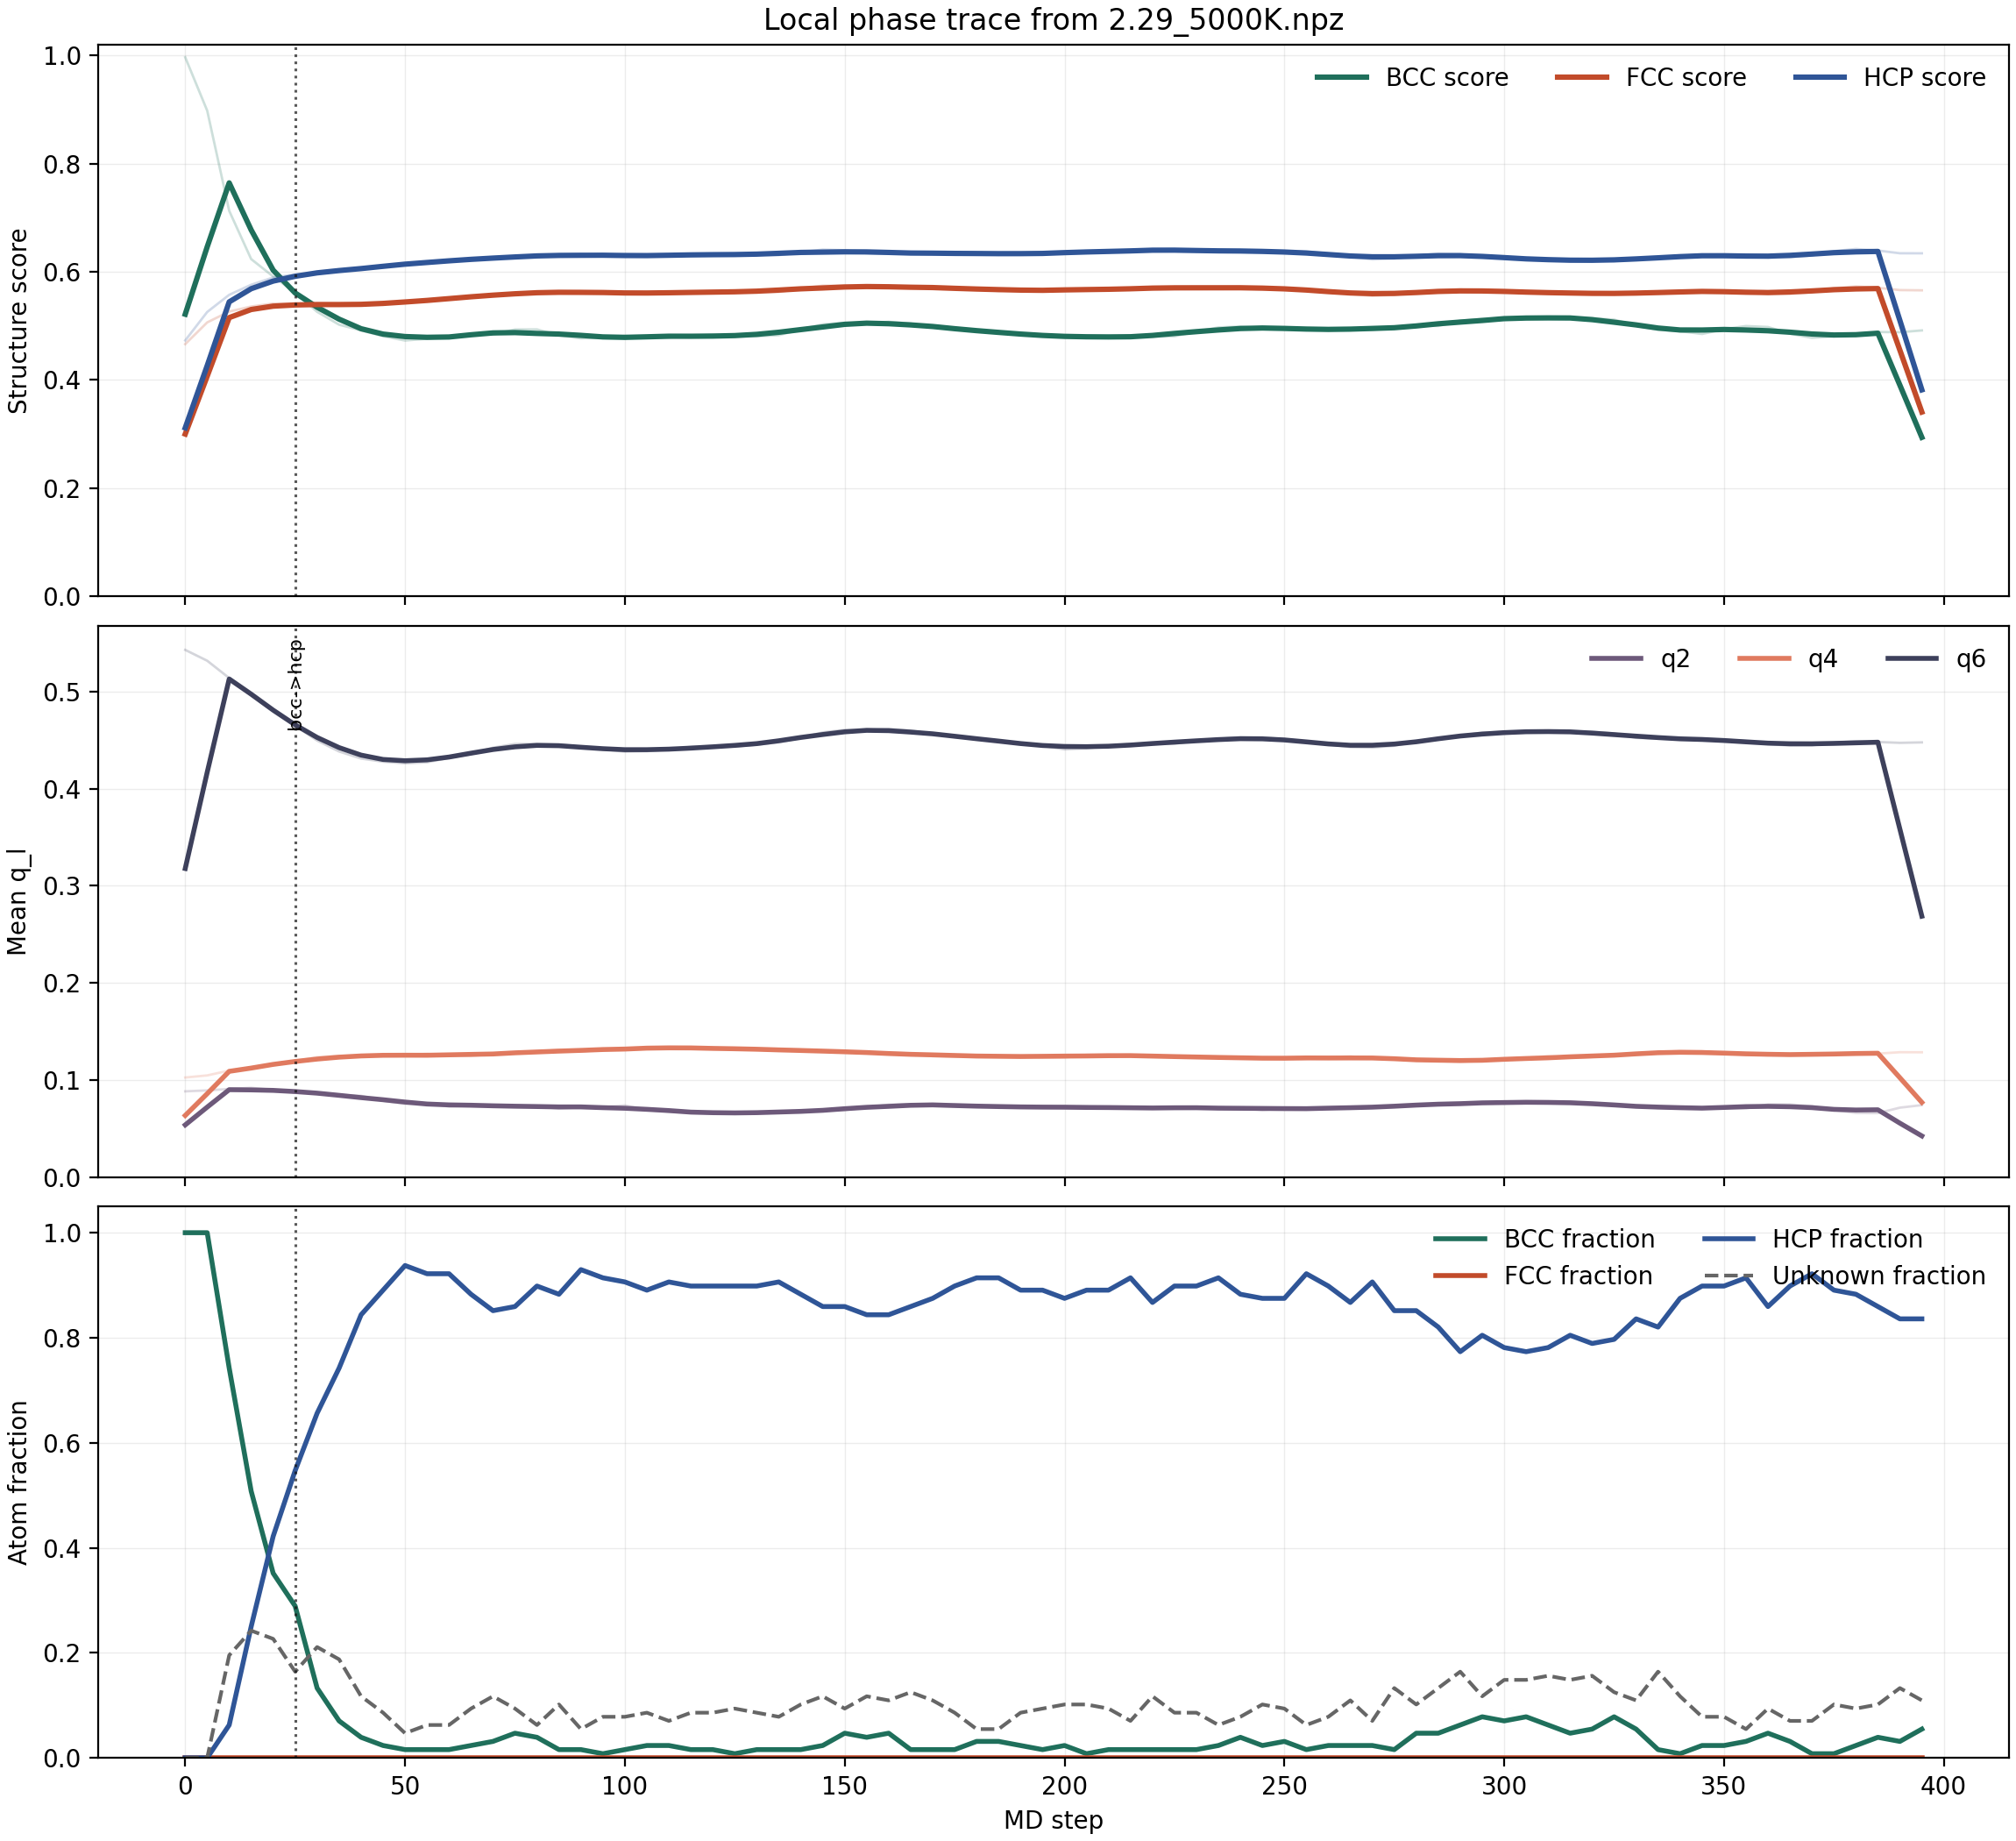

In [ ]:
display(Image(filename=str(plot_path)))

In [16]:
def preview_csv_table(path: Path, limit: int = 12) -> HTML:
    with path.open("r", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        rows = []
        for _, row in zip(range(limit), reader):
            rows.append(row)

    if not rows:
        return HTML("<p><em>No rows found.</em></p>")

    headers = list(rows[0].keys())
    head_html = "".join(f"<th>{html.escape(column)}</th>" for column in headers)
    body_html = "".join(
        "<tr>" + "".join(f"<td>{html.escape(str(row[column]))}</td>" for column in headers) + "</tr>"
        for row in rows
    )
    return HTML(
        "<table style='border-collapse: collapse; font-size: 12px;'>"
        f"<thead><tr>{head_html}</tr></thead>"
        f"<tbody>{body_html}</tbody>"
        "</table>"
    )


display(Markdown("## Phase Trace Preview"))
display(preview_csv_table(csv_path, limit=12))
display(Markdown("## Transition Preview"))
display(preview_csv_table(transitions_path, limit=20))

## Phase Trace Preview

frame_index,step,mean_bcc_score,mean_fcc_score,mean_hcp_score,smoothed_bcc_score,smoothed_fcc_score,smoothed_hcp_score,mean_q2,mean_q4,mean_q6,smoothed_q2,smoothed_q4,smoothed_q6,bcc_fraction,fcc_fraction,hcp_fraction,unknown_fraction,dominant_phase,transition_here
0,0,0.99668900,0.46608634,0.47293513,0.52145491,0.29974464,0.31116066,0.08817951,0.10244023,0.54300407,0.05359518,0.06333190,0.31776102,1.00000000,0.00000000,0.00000000,0.00000000,bcc,no
1,5,0.89789421,0.50628174,0.52557463,0.64613304,0.40687899,0.42634622,0.08916264,0.10459953,0.53181663,0.07195518,0.08577739,0.41699929,1.00000000,0.00000000,0.00000000,0.00000000,bcc,no
2,10,0.71269133,0.52635513,0.55729356,0.76437700,0.51511348,0.54421338,0.09063376,0.10961972,0.51398439,0.08988973,0.10878874,0.51302096,0.74218750,0.00000000,0.06250000,0.19531250,bcc,no
3,15,0.62339066,0.53567175,0.57592778,0.67728426,0.53013131,0.56862501,0.09179997,0.11222748,0.49619137,0.08967717,0.11215910,0.49738186,0.50781250,0.00000000,0.25000000,0.24218750,bcc,no
4,20,0.59121978,0.54117245,0.58933581,0.60287851,0.53634073,0.58272267,0.08967279,0.11505672,0.48010831,0.08917271,0.11595144,0.48093960,0.35156250,0.00000000,0.42187500,0.22656250,bcc,no
5,25,0.56122533,0.54117551,0.59499329,0.56074746,0.53854129,0.59158407,0.08711668,0.11929207,0.46480860,0.08795999,0.11895550,0.46580873,0.28906250,0.00000000,0.54687500,0.16406250,hcp,yes
6,30,0.52586543,0.53732884,0.59606289,0.53437196,0.53933931,0.59794312,0.08664033,0.12356123,0.44960532,0.08631840,0.12143921,0.45278320,0.13281250,0.00000000,0.65625000,0.21093750,hcp,no
7,35,0.50203610,0.53735790,0.60160058,0.51227582,0.53932029,0.60219160,0.08457019,0.12464002,0.43833007,0.08407541,0.12339826,0.44232646,0.07031250,0.00000000,0.74218750,0.18750000,hcp,no
8,40,0.49151314,0.53966185,0.60772302,0.49457826,0.53968168,0.60586306,0.08359203,0.12464600,0.43106369,0.08171891,0.12466457,0.43459618,0.03906250,0.00000000,0.84375000,0.11718750,hcp,no
9,45,0.48073908,0.54107737,0.61057824,0.48464441,0.54140051,0.61003688,0.07845782,0.12485198,0.42782461,0.07955706,0.12531878,0.43011765,0.02343750,0.00000000,0.89062500,0.08593750,hcp,no


## Transition Preview

frame_index,step,from_phase,to_phase
5,25,bcc,hcp
